### Installation
- Pandas
- Matplotlib
- Seaborn


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#readdata
data = pd.read_csv('Gaming_Academic_Performance.csv')

data.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


In [74]:
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
categorical_features = data.select_dtypes(include=['object']).columns
target_variable = 'grades'
numerical_features = numerical_features.drop('grades')
numerical_features = numerical_features.drop('student_id')
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)
print("Target Variable:", target_variable)

Numerical Features: Index(['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
       'social_activity', 'device_usage', 'reaction_time_ms',
       'addiction_score'],
      dtype='object')
Categorical Features: Index(['gender', 'gaming_genre', 'stress_level'], dtype='object')
Target Variable: grades


# 1.Clean Data

## 1.1. Data Understanding

In [75]:
data.describe()

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


In [76]:
data[categorical_features].nunique()

gender          3
gaming_genre    3
stress_level    3
dtype: int64

## 1.2. Check missing value

In [77]:
data.isnull().sum()

student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

Conclusion: There is no null cell in this table

## 1.3. Check duplicate

In [78]:
data.duplicated().sum()

np.int64(0)

Conclusion: There are no duplicate rows in the table

## 1.4. Inconsistant catecorical variables

In [79]:
data.describe()

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


Conclusion: Every numerical columns is consistant

In [80]:
{col: data[col].unique() for col in categorical_features}

{'gender': array(['Male', 'Female', 'Other'], dtype=object),
 'gaming_genre': array(['FPS', 'Casual', 'RPG'], dtype=object),
 'stress_level': array(['Low', 'Medium', 'High'], dtype=object)}

Conclusion: Every categorical columns is consistant and no error

## 1.5. Outliers

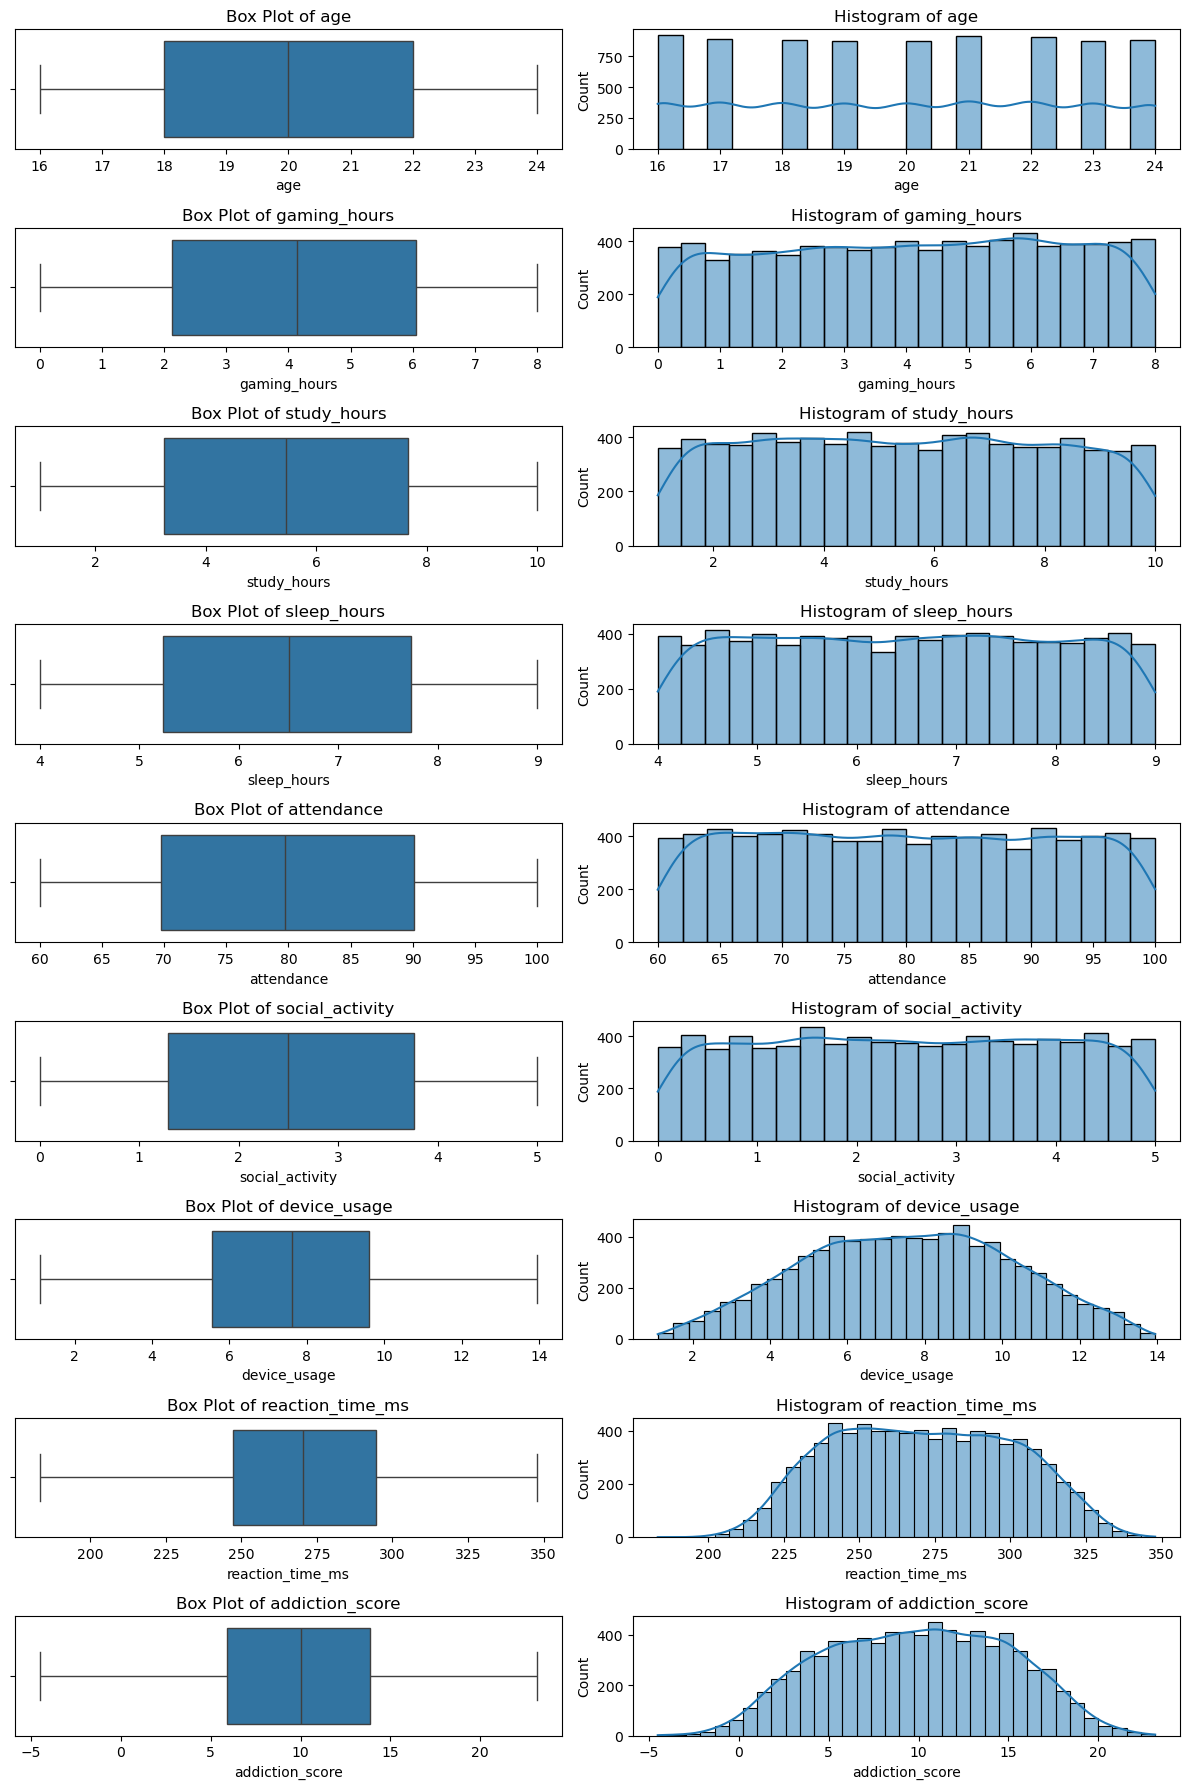

In [81]:
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, 2*len(numerical_features)))
for i, col in enumerate(numerical_features):
    sns.boxplot(x=data[col], ax=axes[i, 0])
    sns.histplot(data[col], kde=True, ax=axes[i, 1])
    axes[i, 0].set_title(f'Box Plot of {col}')
    axes[i, 1].set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


Conclusion: there are no outliers to handle

# 2. Exploratory Data Analysis

## 2.1. Univariate

In [82]:
data[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,8000.0,19.983625,2.587072,16.00,18.0000,20.000,22.00,24.00
gaming_hours,8000.0,4.085773,2.308801,0.00,2.1300,4.130,6.06,8.00
study_hours,8000.0,5.460581,2.575787,1.00,3.2400,5.460,7.66,10.00
sleep_hours,8000.0,6.493453,1.442656,4.00,5.2400,6.505,7.73,9.00
attendance,8000.0,79.886525,11.580419,60.00,69.7800,79.695,90.10,100.00
social_activity,8000.0,2.507790,1.441128,0.00,1.2875,2.500,3.76,5.00
device_usage,8000.0,7.586315,2.710035,1.10,5.5600,7.610,9.60,13.95
reaction_time_ms,8000.0,271.105839,29.440675,183.26,247.1600,270.475,294.69,347.87
addiction_score,8000.0,9.908492,5.035837,-4.51,5.9200,10.005,13.86,23.16


In [83]:
data[numerical_features].skew()


age                -0.002101
gaming_hours       -0.057435
study_hours         0.022475
sleep_hours         0.004045
attendance          0.021198
social_activity    -0.003978
device_usage       -0.010724
reaction_time_ms    0.046683
addiction_score    -0.030470
dtype: float64

<Axes: xlabel='grades', ylabel='Count'>

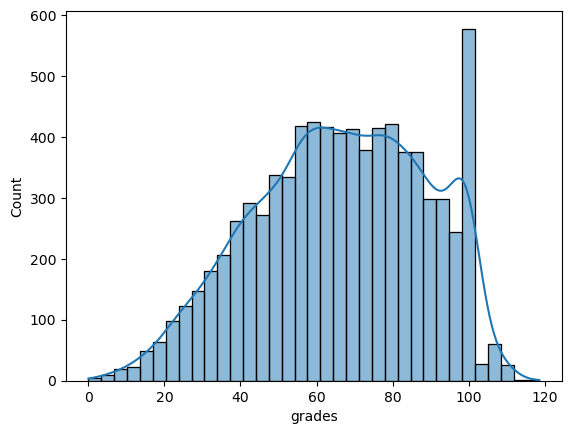

In [84]:
sns.histplot(data[target_variable], kde=True)


Conlusions numerical:
- Age, Gaming hours, Study hours, sleep hours, attendance, social activity follow approcimately uniform distribution across its range
- Device usage, reactiontime and addiction score all exhibit symmetric, flat-stopped distributions

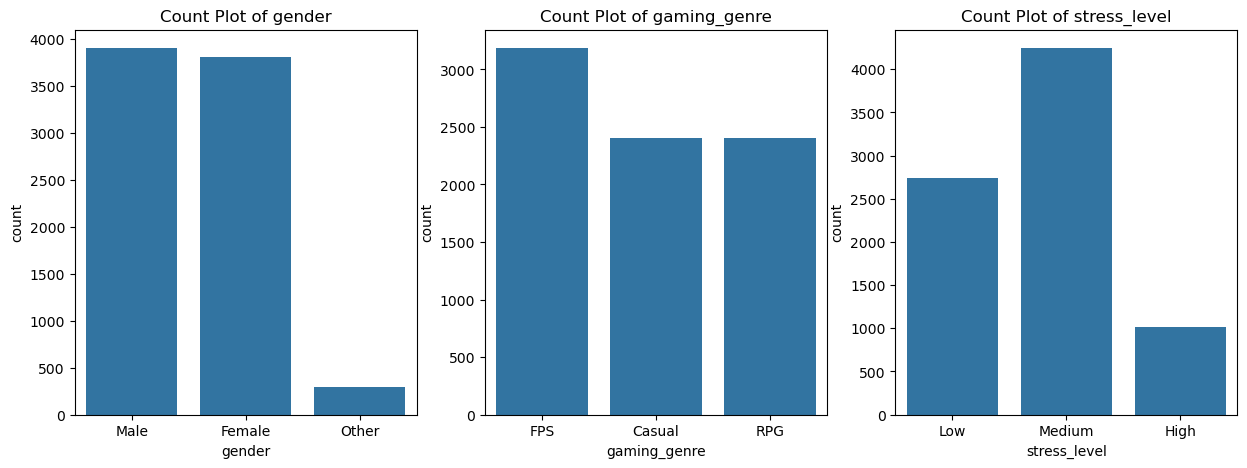

In [85]:
fig, axes = plt.subplots(nrows=1, ncols=len(categorical_features), figsize=(15, 5))
for i, col in enumerate(categorical_features):
    sns.countplot(x=col, data=data, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}')
plt.show()

Conclusions for categorical category:
- what sould i do